In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import stats
from scipy.stats import gaussian_kde

from sklearn.decomposition import PCA

In [18]:
DATA_DIR = Path().resolve().parent / "data" 
FOLD = 1
H = 5                
DIM = 10                  
SELECTED_DIMENSION = 144   
MAX_POINTS = 200_000       
FEATURE_IDX = 0           


In [19]:
fold = 1   
selected_dimension = 144     
dim = 10                   
h = 5                      
feature_idx = 0             

max_points = 5000           
ma_window = 500           
acf_lags = 200  

In [54]:
import matplotlib as mpl

def set_christmas_theme_cozy():
    mpl.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.color": "#ffffff",
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "legend.frameon": True,
        "legend.framealpha": 0.85,
        "legend.fancybox": True,
        "lines.linewidth": 2.3,
    })


    mpl.rcParams["figure.facecolor"] = "#0b1220"
    mpl.rcParams["axes.facecolor"] = "#0f1a2b"
    mpl.rcParams["text.color"] = "#f7f7f7"
    mpl.rcParams["axes.labelcolor"] = "#f7f7f7"
    mpl.rcParams["xtick.color"] = "#f7f7f7"
    mpl.rcParams["ytick.color"] = "#f7f7f7"
    mpl.rcParams["axes.edgecolor"] = "#f7f7f7"

    christmas_cycle = ["#2ECC71", "#E74C3C", "#F1C40F", "#5DADE2", "#AF7AC5"]
    mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=christmas_cycle)

set_christmas_theme_cozy()

def add_snow(ax, n=120, seed=42, alpha=0.12, size=(5, 30), zorder=10, clip_on=True):

    rng = np.random.default_rng(seed)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    xlow, xhigh = (xmin, xmax) if xmin <= xmax else (xmax, xmin)
    ylow, yhigh = (ymin, ymax) if ymin <= ymax else (ymax, ymin)

    xs = rng.uniform(xlow, xhigh, n)
    ys = rng.uniform(ylow, yhigh, n)
    ss = rng.uniform(size[0], size[1], n)

    ax.scatter(xs, ys, s=ss, c="white", alpha=alpha, linewidths=0,
               zorder=zorder, clip_on=clip_on)

def snowify(ax, strength="light", seed=42):

    if strength == "light":
        add_snow(ax, n=120, seed=seed, alpha=0.10, size=(6, 22), zorder=10)
    elif strength == "medium":
        add_snow(ax, n=200, seed=seed, alpha=0.12, size=(6, 26), zorder=10)
    elif strength == "heavy":
        add_snow(ax, n=320, seed=seed, alpha=0.14, size=(6, 30), zorder=10)



def maybe_decimate(x, max_points=MAX_POINTS):

    if max_points is None:
        return x, None
    n = len(x)
    if n <= max_points:
        return x, None
    idx = np.linspace(0, n-1, max_points, dtype=int)
    return x[idx], idx

def load_fold(fold=FOLD, data_dir=DATA_DIR):
    train_path = data_dir / "training" / f"Train_Dst_NoAuction_ZScore_CF_{fold}.txt"
    test_path  = data_dir / "testing"  / f"Test_Dst_NoAuction_ZScore_CF_{fold}.txt"

    dec_train = np.loadtxt(train_path)
    dec_test  = np.loadtxt(test_path)

    X_train = dec_train[:SELECTED_DIMENSION, :].T.astype(np.float32)
    X_test  = dec_test[:SELECTED_DIMENSION, :].T.astype(np.float32)

    y_train = dec_train[-H, :].astype(np.int64).flatten()[DIM-1:] - 1
    y_test  = dec_test[-H, :].astype(np.int64).flatten()[DIM-1:] - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_fold()
print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Test  X:", X_test.shape,  "Test  y:", y_test.shape)


Train X: (39512, 144) Train y: (39503,)
Test  X: (38397, 144) Test  y: (38388,)


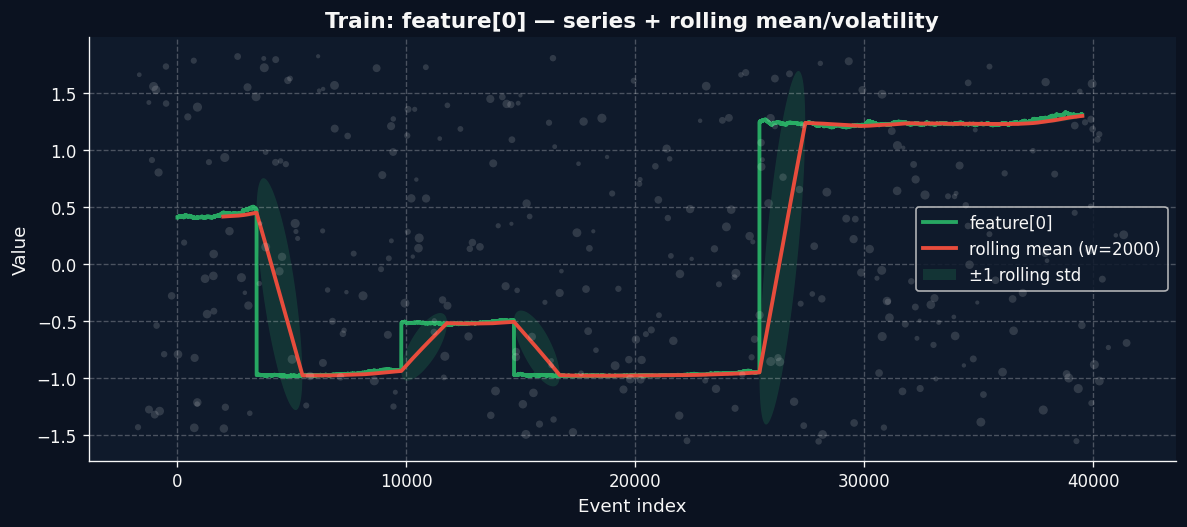

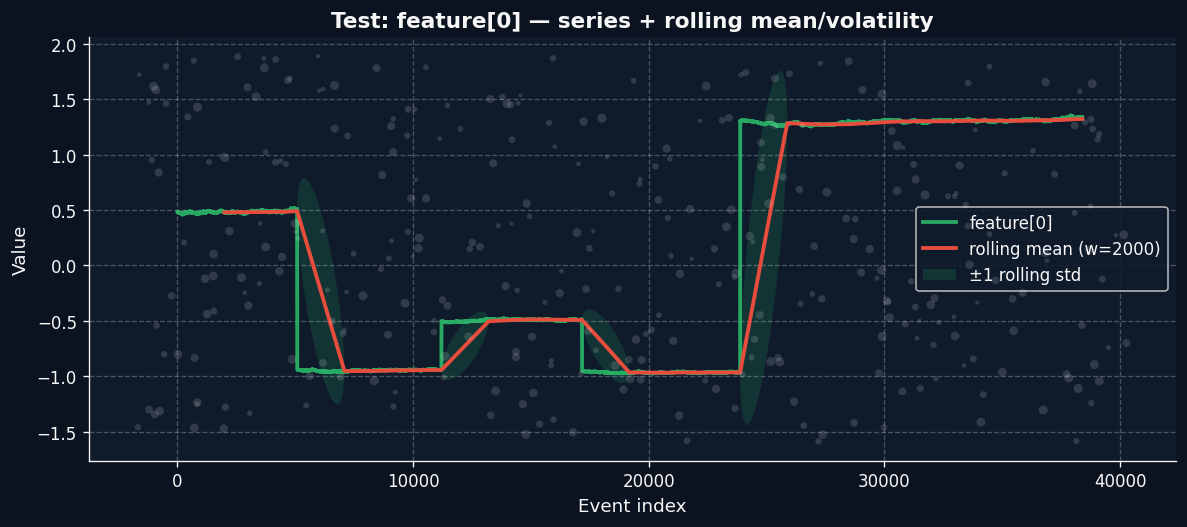

In [56]:
def rolling_mean_std(x, window):
    if window <= 1:
        return x.copy(), np.zeros_like(x)
    w = int(window)

    mean = np.convolve(x, np.ones(w)/w, mode="valid")
    sq   = np.convolve(x**2, np.ones(w)/w, mode="valid")
    std  = np.sqrt(np.maximum(sq - mean**2, 0))
    t = np.arange(w-1, w-1+len(mean))
    return (t, mean, std)

def plot_feature_timeseries(x, feature_idx=FEATURE_IDX, window=2000, title_prefix="Train",
                            snow_strength="heavy", snow_seed=1):
    s = x[:, feature_idx]
    s_plot, idx = maybe_decimate(s)
    t_plot = np.arange(len(s_plot)) if idx is None else idx

    plt.figure(figsize=(10, 4.5))
    plt.plot(t_plot, s_plot, alpha=0.8, label=f"feature[{feature_idx}]")

    t_roll, m, sd = rolling_mean_std(s, window)

    m_plot, m_idx = maybe_decimate(m)
    t_roll_plot = t_roll if m_idx is None else t_roll[m_idx]
    sd_plot = sd if m_idx is None else sd[m_idx]

    plt.plot(t_roll_plot, m_plot, label=f"rolling mean (w={window})")
    plt.fill_between(t_roll_plot, m_plot - sd_plot, m_plot + sd_plot, alpha=0.15, label="±1 rolling std")

    plt.title(f"{title_prefix}: feature[{feature_idx}] — series + rolling mean/volatility")
    plt.xlabel("Event index")
    plt.ylabel("Value")
    plt.legend(loc="best")

    ax = plt.gca()
    snowify(ax, strength=snow_strength, seed=snow_seed)

    plt.tight_layout()
    plt.show()


plot_feature_timeseries(X_train, feature_idx=FEATURE_IDX, window=2000, title_prefix="Train")
plot_feature_timeseries(X_test,  feature_idx=FEATURE_IDX, window=2000, title_prefix="Test")

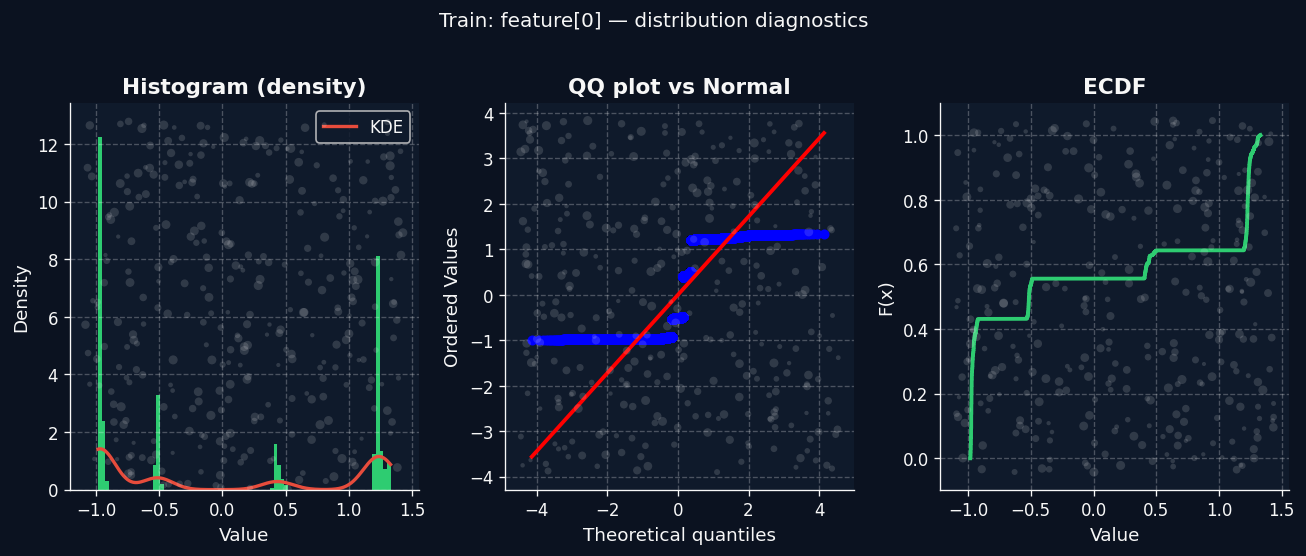

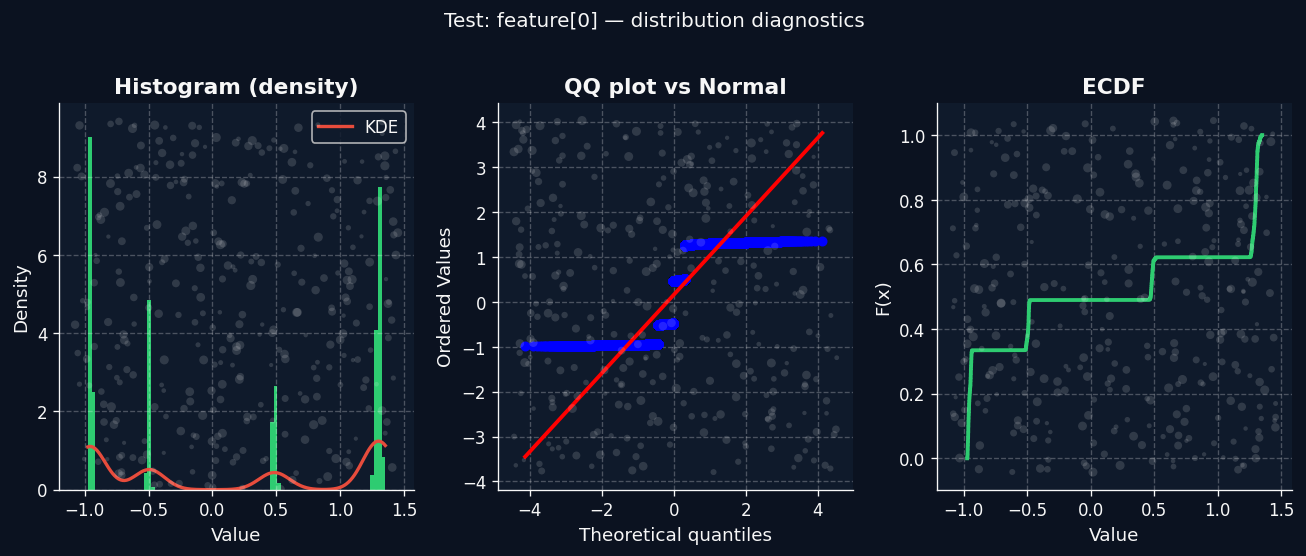

In [58]:
def plot_distribution_diagnostics(x, feature_idx=FEATURE_IDX, title_prefix="Train", bins=80,
                                  snow_strength="heavy", snow_seed=10):
    s = x[:, feature_idx]
    s_plot, _ = maybe_decimate(s)

    fig = plt.figure(figsize=(11, 4.5))
    gs = fig.add_gridspec(1, 3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(s_plot, bins=bins, density=True)
    ax1.set_title("Histogram (density)")
    ax1.set_xlabel("Value")
    ax1.set_ylabel("Density")

    if gaussian_kde is not None:
        kde = gaussian_kde(s_plot)
        xs = np.linspace(s_plot.min(), s_plot.max(), 300)
        ax1.plot(xs, kde(xs), linewidth=2, label="KDE")
        ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    if stats is not None:
        stats.probplot(s_plot, dist="norm", plot=ax2)
        ax2.set_title("QQ plot vs Normal")
    else:
        ax2.text(0.5, 0.5, "SciPy not installed\n(QQ plot unavailable)",
                 ha="center", va="center")
        ax2.set_axis_off()

    ax3 = fig.add_subplot(gs[0, 2])
    xs = np.sort(s_plot)
    ys = np.linspace(0, 1, len(xs), endpoint=True)
    ax3.plot(xs, ys)
    ax3.set_title("ECDF")
    ax3.set_xlabel("Value")
    ax3.set_ylabel("F(x)")

    snowify(ax1, strength=snow_strength, seed=snow_seed + 0)
    if ax2.axison:
        snowify(ax2, strength=snow_strength, seed=snow_seed + 1)
    snowify(ax3, strength=snow_strength, seed=snow_seed + 2)

    fig.suptitle(f"{title_prefix}: feature[{feature_idx}] — distribution diagnostics", y=1.02)
    fig.tight_layout()
    plt.show()


plot_distribution_diagnostics(X_train, feature_idx=FEATURE_IDX, title_prefix="Train")
plot_distribution_diagnostics(X_test,  feature_idx=FEATURE_IDX, title_prefix="Test")


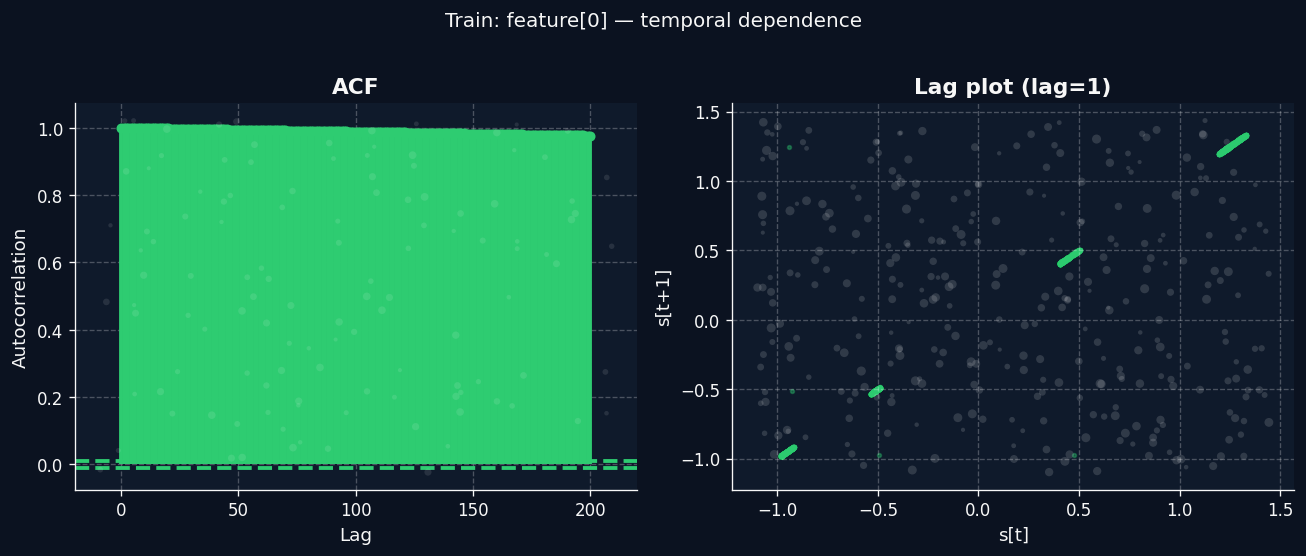

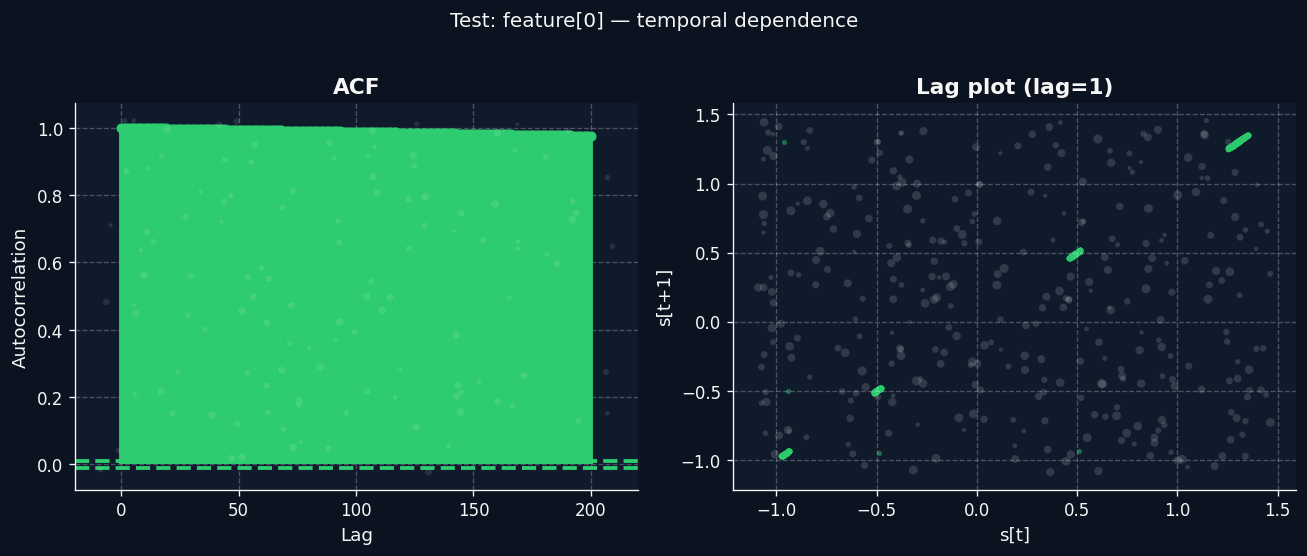

In [59]:
def acf_numpy(x, nlags=200):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    if denom == 0:
        return np.zeros(nlags+1)
    acf = [1.0]
    for k in range(1, nlags+1):
        acf.append(np.dot(x[:-k], x[k:]) / denom)
    return np.array(acf)

def plot_acf_and_lag(x, feature_idx=FEATURE_IDX, nlags=200, lag=1, title_prefix="Train",
                     snow_strength="heavy", snow_seed=20):
    s = x[:, feature_idx]
    s_plot, _ = maybe_decimate(s)

    fig = plt.figure(figsize=(11, 4.5))
    gs = fig.add_gridspec(1, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    acf = acf_numpy(s_plot, nlags=nlags)
    ax1.stem(range(nlags+1), acf, basefmt=" ")
    ax1.set_title("ACF")
    ax1.set_xlabel("Lag")
    ax1.set_ylabel("Autocorrelation")

    conf = 1.96 / np.sqrt(len(s_plot))
    ax1.axhline(conf, linestyle="--")
    ax1.axhline(-conf, linestyle="--")

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(s_plot[:-lag], s_plot[lag:], s=5, alpha=0.35)
    ax2.set_title(f"Lag plot (lag={lag})")
    ax2.set_xlabel("s[t]")
    ax2.set_ylabel(f"s[t+{lag}]")

    snowify(ax1, strength="light", seed=snow_seed + 0)

    snowify(ax2, strength=snow_strength, seed=snow_seed + 1)

    fig.suptitle(f"{title_prefix}: feature[{feature_idx}] — temporal dependence", y=1.02)
    fig.tight_layout()
    plt.show()


plot_acf_and_lag(X_train, feature_idx=FEATURE_IDX, nlags=200, lag=1, title_prefix="Train")
plot_acf_and_lag(X_test,  feature_idx=FEATURE_IDX, nlags=200, lag=1, title_prefix="Test")

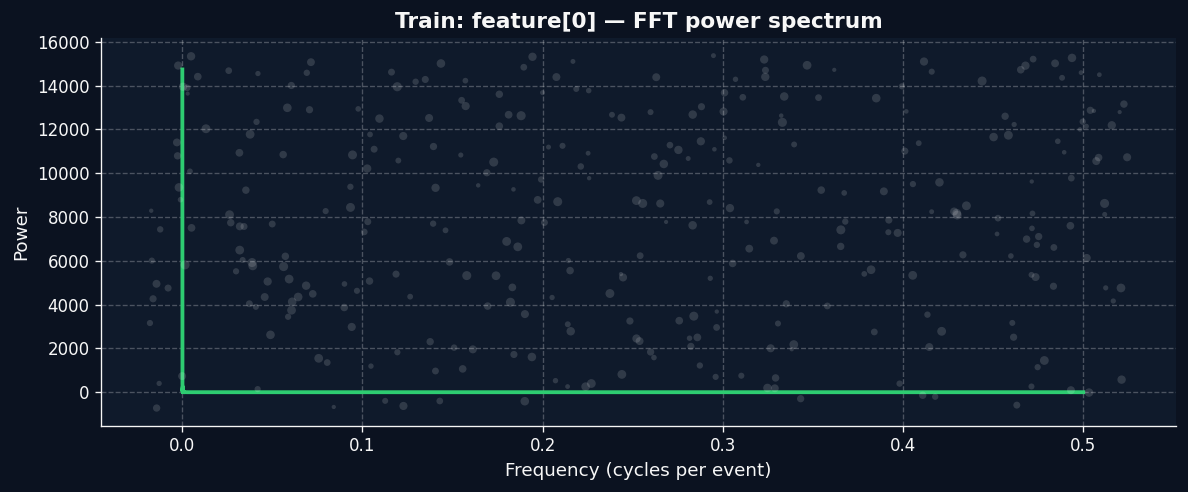

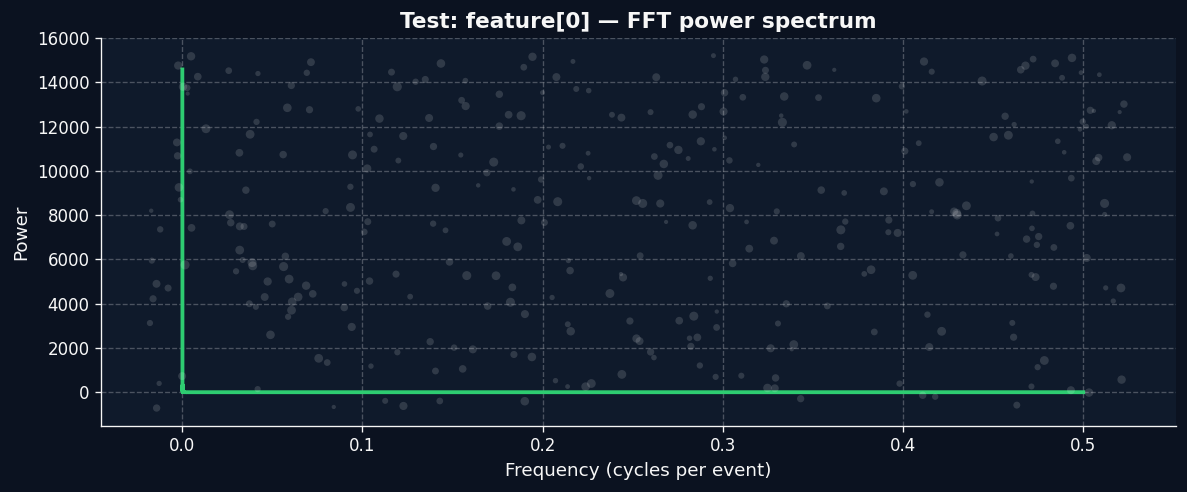

In [61]:
def plot_psd(x, feature_idx=FEATURE_IDX, title_prefix="Train",
             snow_strength="heavy", snow_seed=30):
    s = x[:, feature_idx]
    s_plot, _ = maybe_decimate(s)

    s0 = s_plot - s_plot.mean()
    n = len(s0)

    fft = np.fft.rfft(s0)
    psd = (np.abs(fft)**2) / n
    freq = np.fft.rfftfreq(n, d=1.0)

    plt.figure(figsize=(10, 4.2))
    plt.plot(freq[1:], psd[1:])
    plt.title(f"{title_prefix}: feature[{feature_idx}] — FFT power spectrum")
    plt.xlabel("Frequency (cycles per event)")
    plt.ylabel("Power")

    ax = plt.gca()
    snowify(ax, strength=snow_strength, seed=snow_seed)

    plt.tight_layout()
    plt.show()


plot_psd(X_train, feature_idx=FEATURE_IDX, title_prefix="Train")
plot_psd(X_test,  feature_idx=FEATURE_IDX, title_prefix="Test")

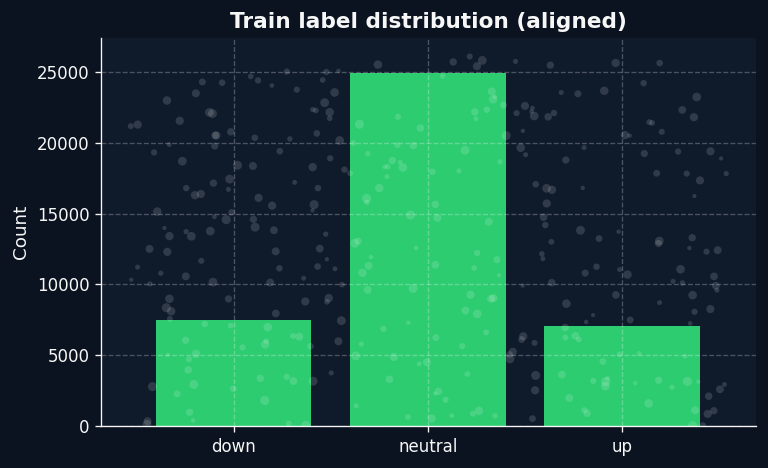

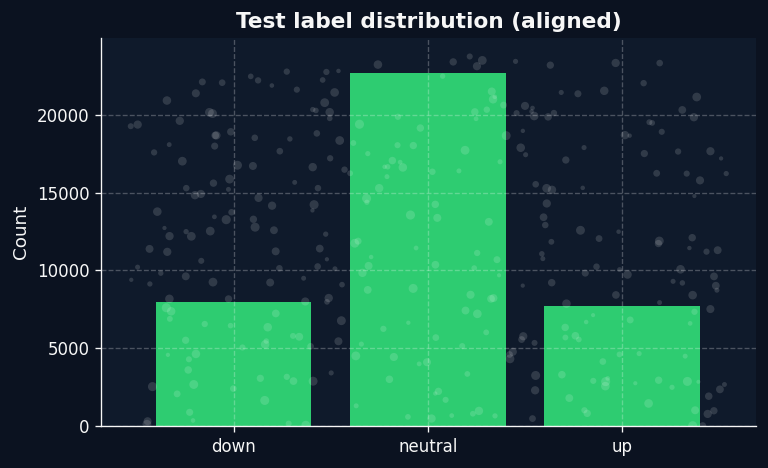

In [63]:
def plot_label_distribution(y, title="Label distribution",
                            snow_strength="heavy", snow_seed=40):
    vals, counts = np.unique(y, return_counts=True)

    counts_full = [counts[list(vals).index(k)] if k in vals else 0 for k in [0, 1, 2]]

    plt.figure(figsize=(6.5, 4))
    plt.bar([0, 1, 2], counts_full)
    plt.xticks([0, 1, 2], ["down", "neutral", "up"])
    plt.ylabel("Count")
    plt.title(title)

    ax = plt.gca()
    snowify(ax, strength=snow_strength, seed=snow_seed)

    plt.tight_layout()
    plt.show()


plot_label_distribution(y_train, title="Train label distribution (aligned)")
plot_label_distribution(y_test,  title="Test label distribution (aligned)")

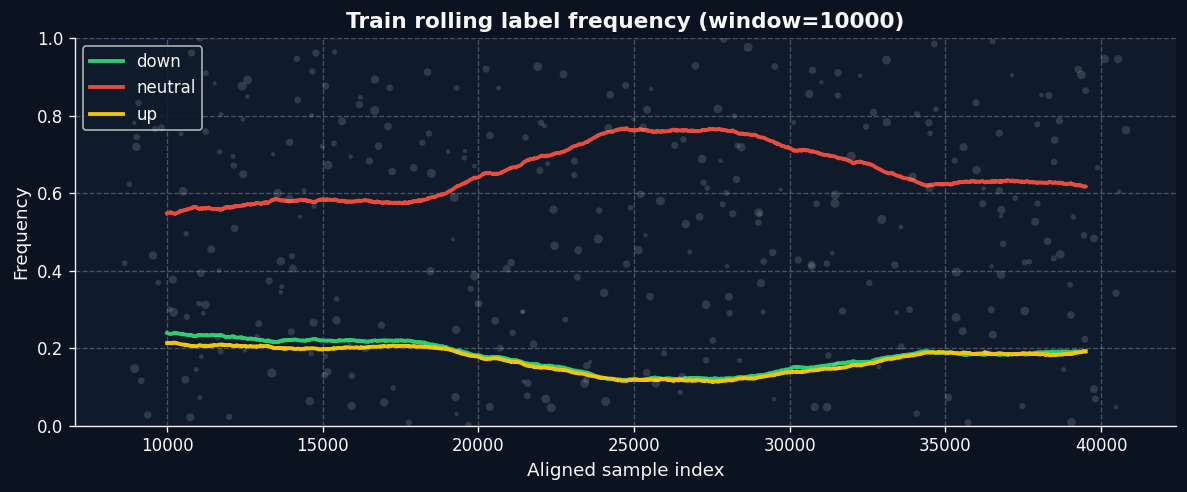

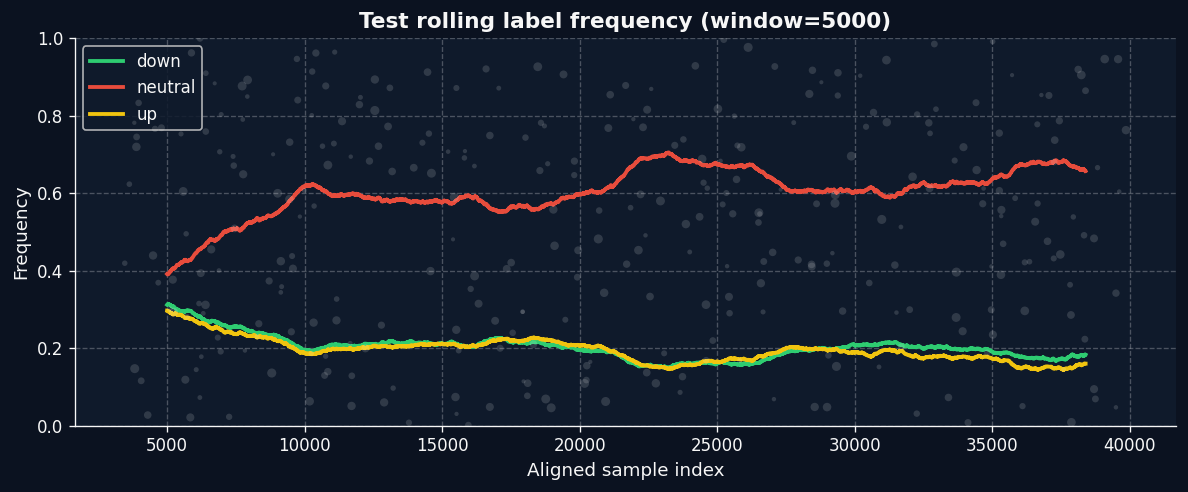

In [64]:
def rolling_label_freq(y, window=10_000):
    y = np.asarray(y)
    n = len(y)
    if n < window:
        window = max(10, n//5)
    t = np.arange(window-1, n)
    freqs = np.zeros((len(t), 3), dtype=float)

    for k in [0,1,2]:
        z = (y == k).astype(int)
        c = np.cumsum(z)

        counts = c[window-1:] - np.concatenate(([0], c[:-window]))
        freqs[:, k] = counts / window
    return t, freqs

def plot_rolling_label_freq(y, title="Rolling label frequency", window=10_000,
                            snow_strength="heavy", snow_seed=50):
    t, freqs = rolling_label_freq(y, window=window)

    plt.figure(figsize=(10, 4.2))
    plt.plot(t, freqs[:, 0], label="down")
    plt.plot(t, freqs[:, 1], label="neutral")
    plt.plot(t, freqs[:, 2], label="up")

    plt.title(f"{title} (window={window})")
    plt.xlabel("Aligned sample index")
    plt.ylabel("Frequency")
    plt.ylim(0, 1)
    plt.legend()

    ax = plt.gca()
    snowify(ax, strength=snow_strength, seed=snow_seed)

    plt.tight_layout()
    plt.show()


plot_rolling_label_freq(y_train, title="Train rolling label frequency", window=10_000)
plot_rolling_label_freq(y_test,  title="Test rolling label frequency",  window=5_000)

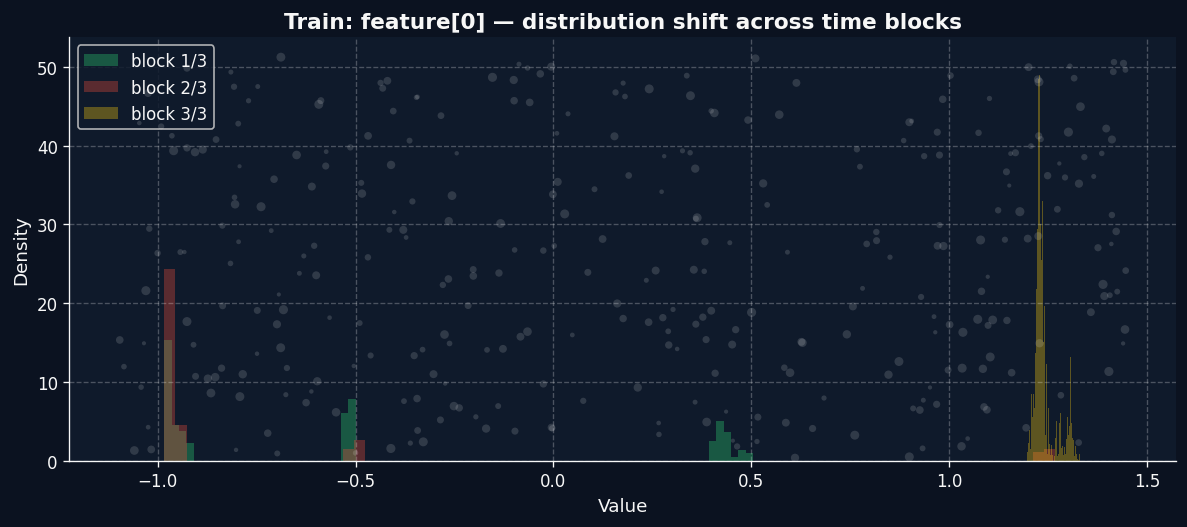

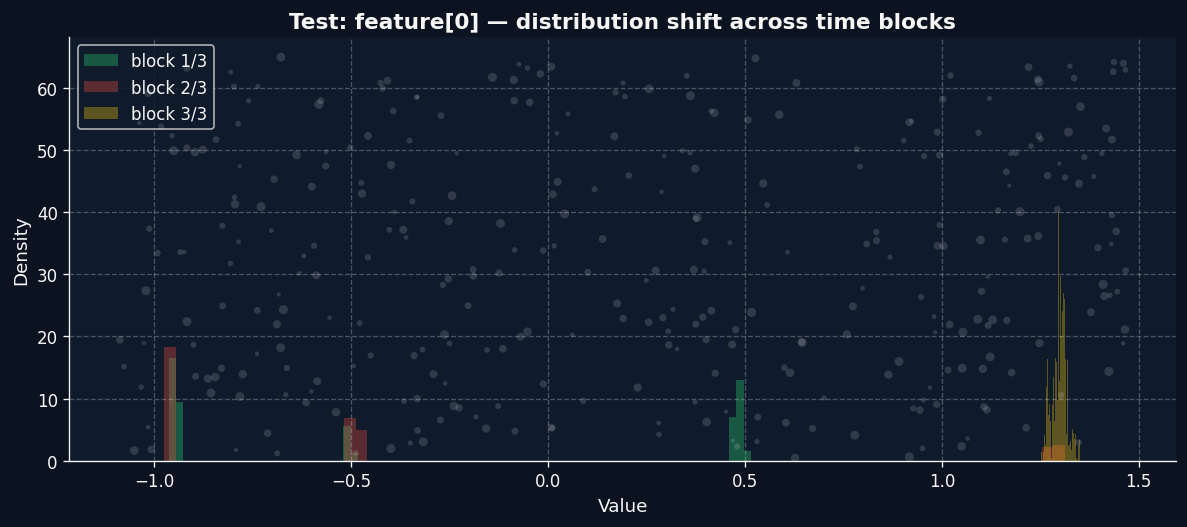

In [65]:
def plot_feature_shift_blocks(x, feature_idx=FEATURE_IDX, blocks=3, title_prefix="Train", bins=80,
                              snow_strength="heavy", snow_seed=60):
    s = x[:, feature_idx]
    n = len(s)
    edges = np.linspace(0, n, blocks+1, dtype=int)

    plt.figure(figsize=(10, 4.5))
    for b in range(blocks):
        seg = s[edges[b]:edges[b+1]]
        seg_plot, _ = maybe_decimate(seg)
        plt.hist(seg_plot, bins=bins, density=True, alpha=0.35, label=f"block {b+1}/{blocks}")

    plt.title(f"{title_prefix}: feature[{feature_idx}] — distribution shift across time blocks")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()

    ax = plt.gca()
    snowify(ax, strength=snow_strength, seed=snow_seed)

    plt.tight_layout()
    plt.show()


plot_feature_shift_blocks(X_train, feature_idx=FEATURE_IDX, blocks=3, title_prefix="Train")
plot_feature_shift_blocks(X_test,  feature_idx=FEATURE_IDX, blocks=3, title_prefix="Test")

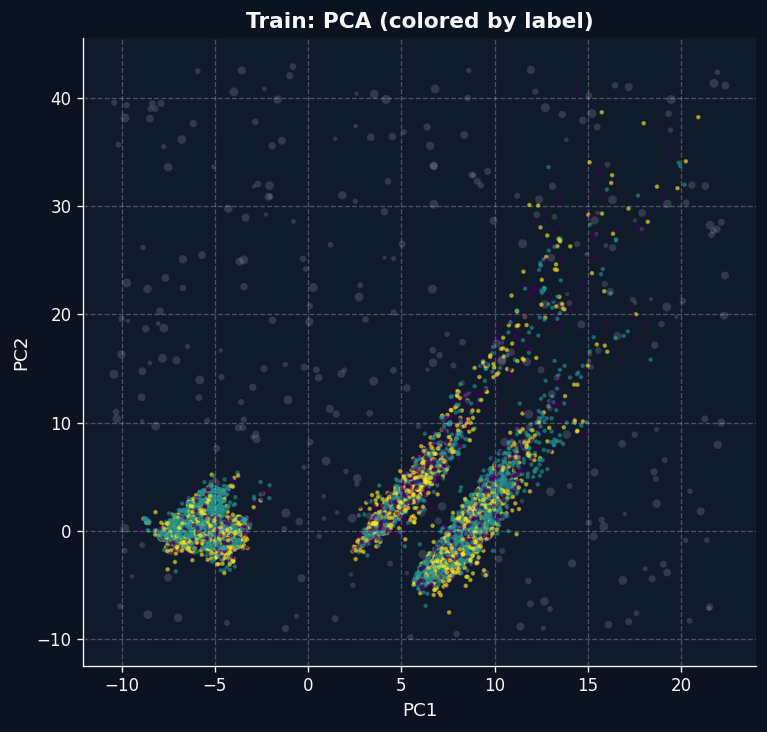

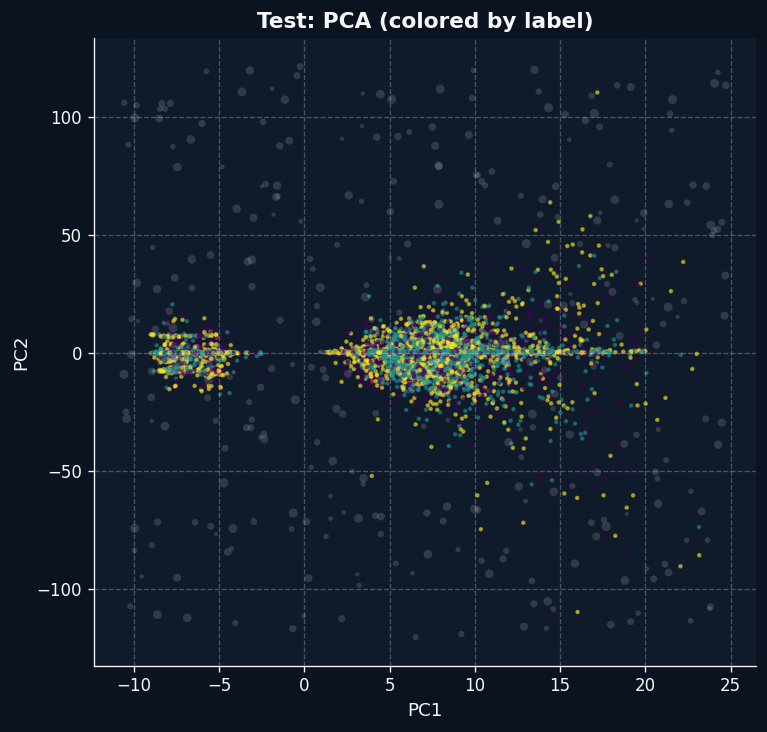

In [66]:
def plot_pca_embedding(X, y, title="PCA embedding (2D)", max_points=80_000,
                       snow_strength="heavy", snow_seed=70):
    if PCA is None:
        print("sklearn not installed: PCA plot unavailable")
        return

    X_aligned = X[DIM-1:, :]
    y_aligned = y

    if len(y_aligned) > max_points:
        idx = np.linspace(0, len(y_aligned)-1, max_points, dtype=int)
        X_aligned = X_aligned[idx]
        y_aligned = y_aligned[idx]

    Z = PCA(n_components=2).fit_transform(X_aligned)

    plt.figure(figsize=(6.5, 6.2))
    plt.scatter(Z[:, 0], Z[:, 1], c=y_aligned, s=3, alpha=0.5)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    ax = plt.gca()
    snowify(ax, strength=snow_strength, seed=snow_seed)

    plt.tight_layout()
    plt.show()


plot_pca_embedding(X_train, y_train, title="Train: PCA (colored by label)")
plot_pca_embedding(X_test,  y_test,  title="Test: PCA (colored by label)")


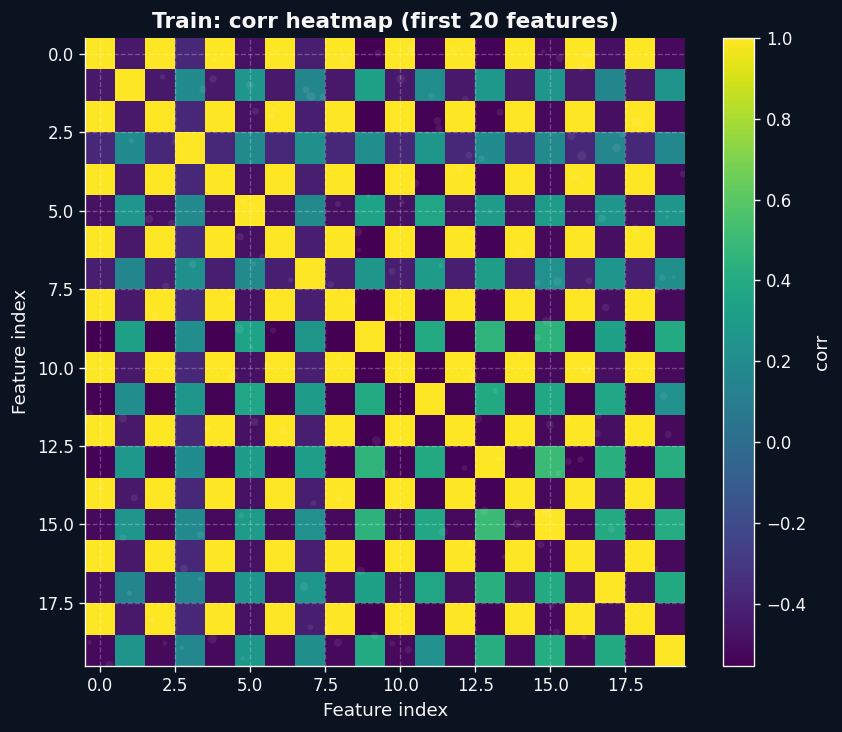

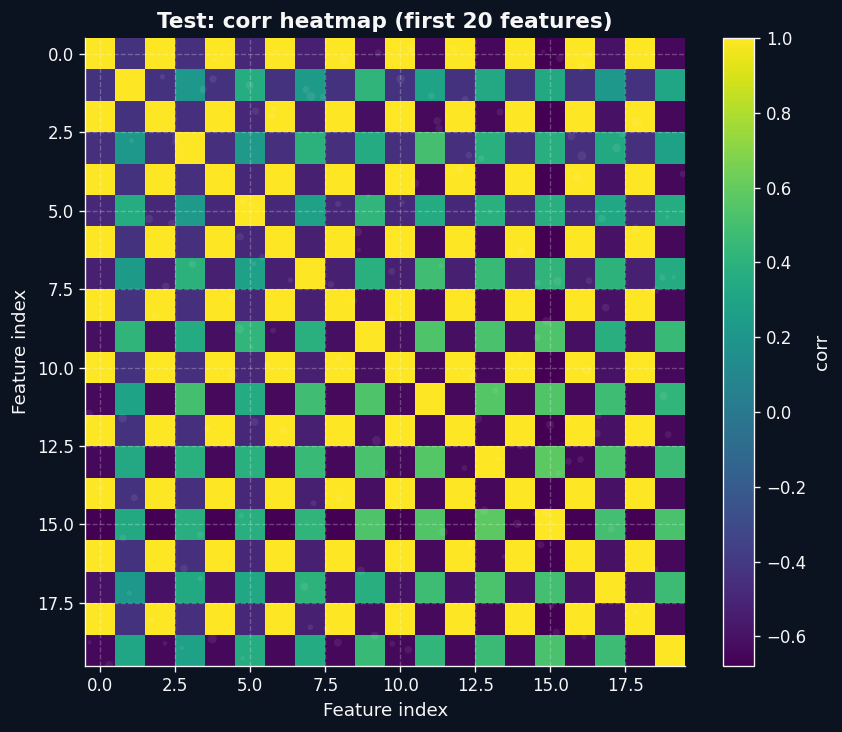

In [53]:
def plot_corr_heatmap(X, n_features=20, title="Correlation heatmap"):
    X0 = X[:, :n_features]
    C = np.corrcoef(X0, rowvar=False)

    plt.figure(figsize=(7.2, 6.2))
    im = plt.imshow(C, aspect="auto")
    plt.colorbar(im, label="corr")
    plt.title(title)
    plt.xlabel("Feature index")
    plt.ylabel("Feature index")

    ax = plt.gca()
    add_snow(ax, n=150, seed=1, alpha=0.08, zorder=3)

    plt.tight_layout()
    plt.show()

plot_corr_heatmap(X_train, n_features=20, title="Train: corr heatmap (first 20 features)")
plot_corr_heatmap(X_test,  n_features=20, title="Test: corr heatmap (first 20 features)")